# Simple inductor analysis
This Notebook generates a single loop inductor and characterizes it using mathematical methods. This is meant to be the starting point for an OpenEMS pipeline for characterization of more complex geometries.

In [1]:
import gdsfactory as gf
import numpy as np
from ihp import LAYER, PDK, tech

PDK.activate()

In [2]:
# All dimensions are in microns by default
d_out = 100
w     = 10.5
s     = 3
N     = 1

In [3]:
# Validate dimensions against PDK parameters
assert w > tech.TECH.metal5_width

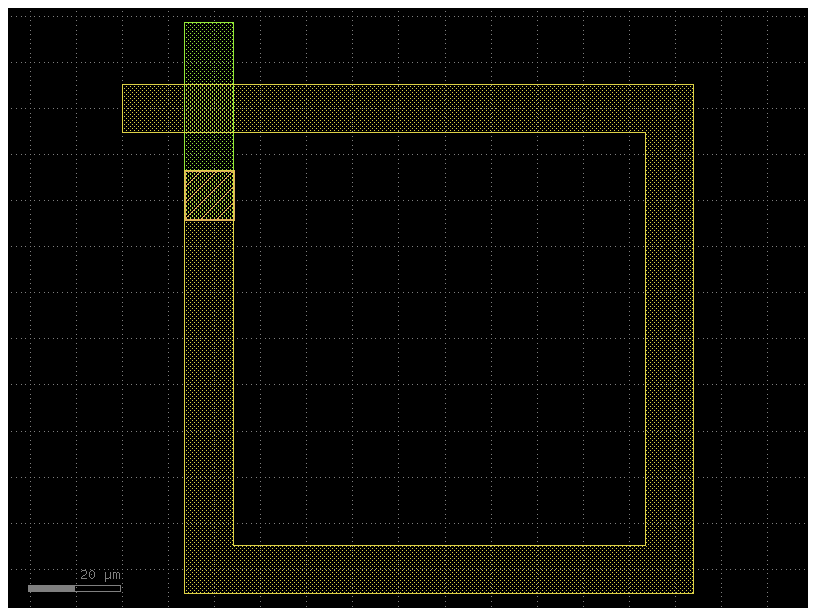

In [ ]:
# Draw the inductor using GDSfactory
P = gf.Path()
a = d_out

# Make some room for the port
P += gf.path.straight(length=w + s, npoints=2)

# Draw the only turn
P += gf.path.straight(length=a + w/2, npoints=2)
P.end_angle -= 90
P += gf.path.straight(length=a, npoints=2)
P.end_angle -= 90
P += gf.path.straight(length=a, npoints=2)
P.end_angle -= 90
a -= w + s
P += gf.path.straight(length=a, npoints=2)

c = gf.Component()
ind = c << gf.path.extrude(P, layer=LAYER.Metal5drawing, width=w)

# Add a small segment on another layer to exit the loop
e_start_point = P.points[-1]
e_start_point -= [0, w]
E = gf.Path([e_start_point])
E.start_angle = 90
E.end_angle = 90
E += gf.path.straight(length = 2 *s + w/2 + 3*w, npoints=2)
ind_e = c << gf.path.extrude(E, layer=LAYER.Metal4drawing, width=w)

# Draw a via to connect both segments
## Note: This is a unified via, a grid of smaller vias could be used as well
v_start_point = E.points[0]
V = gf.Path([v_start_point])
V.start_angle = 90
V.end_angle = 90
V += gf.path.straight(length = w, npoints=2)
ind_v = c << gf.path.extrude(V, layer=LAYER.Via4drawing, width=w)

c.write_gds(".out/simple_inductor.gds")
c.plot()

## Mathematical characterization
Now we need to obtain this inductor's series inductance, resistance and capacitance, as well as the parasitic capacitance between the metal layer and the substrate. This way we can obtain a two port network model and the S-parameters.

### Inductance

The series inductance can be obtained from
$$
L = \frac{\mu n^2 d_\mathrm{avg} c_1}{2} \left[\ln\left(\frac{c_2}{\rho}\right) +c_3\rho + c_4\rho^2\right]
$$
where $n$ is the number of turns, $d_\mathrm{avg}$ is the average of the inner and outer diameters, and $\rho$ is a _fill factor_, defined as
$$
\rho \equiv \frac{d_\mathrm{out} - d_\mathrm{in}}{d_\mathrm{out} + d_\mathrm{in}}
$$

_Reference: Planar Microwave Engineering, Thomas Lee_

In [5]:
mu_0 = 4 * np.pi * 1e-7
mu_r = 1
mu   = mu_0 * mu_r
d_in = d_out - (w + s) * round(N)
d_avg = (d_out + d_in)/2 * 1e-6  # Diameters are defined in microns, convert them to meters
rho = (d_out - d_in)/(d_out + d_in)
c1, c2, c3, c4 = 1.27, 2.07, 0.18, 0.13

L = mu * N**2 * d_avg * c1 / 2 * (np.log(c2/rho)+c3*rho+c4*rho**2)
L

np.float64(2.5053918000870154e-10)

So the series inductance is $250\,\mathrm{pH}$

### Resistance

#### Series resistance
Series resistance depends on resistivity, which in turn is affected by skin depth. This means that series resistance is a function of frequency. The skin depth formula is
$$
\delta = \sqrt{\frac{2\rho}{\omega\mu}\left(\sqrt{1+(\rho\omega\epsilon)^2}+\rho\omega\epsilon\right)}
$$
where $\rho$ is the resisitivity of the material.

For Metal5 in SG13G2, the resistivity of the conductor is $\rho=43.12\,[\mathrm{n}\Omega\cdot\mathrm{m}]$. This means the skin depth formula becomes
$$
\delta = \sqrt{\frac{86.244\,[\mathrm{n}\Omega\cdot\mathrm{m}]}{4\pi\times10^{-7}\omega\,[\mathrm{N}\mathrm{A}^{-2}]}
\left(\sqrt{
1+(381.81\,[\mathrm{z}\Omega\mathrm{F}]\,\omega)^2} + 381.81\,[\mathrm{z}\Omega\mathrm{F}]\,\omega
\right)}
$$
since both relative permittivity and permeability are $1$.

In [6]:
epsilon_0 = 8.854187e-12
mu_0 = 4 * np.pi * 1e-7

metal_5_conductivity = 23.19e6
rho_m5 = 1 / metal_5_conductivity

rho_m5

4.3122035360068996e-08

In [7]:
rho_m5 * epsilon_0

def skin_depth(omega):
    inner_sqrt = np.sqrt(1 + (rho_m5 * epsilon_0 * omega)**2)
    paren = inner_sqrt + rho_m5 * epsilon_0 * omega
    return np.sqrt(2*rho_m5/(mu_0*omega) * paren)

# example: 2.4 GHz
skin_depth(2*np.pi * 2.5e9)

np.float64(2.09025732625266e-06)

It's important to compare the obtained skin depth to the thickness of the conductor. In ihp's metal5 layer, the conductor is $490\,\mathrm{nm}$ thick, so at $2.4\,\mathrm{GHz}$ no skin effect occurs.

Using the obtained skin depth, we can easily obtain the series resistance from
$$
R = \frac{\rho l}{A} = \frac{\rho l}{w\delta},
$$
where $w$ is the width of the conductor and $l$ the total length.

In [8]:
l_m5 = 0
current_point = P.points[0]
for point in P.points[1:]:
    l_m5 += np.linalg.norm(current_point - point)
    current_point = point

# Convert micrometers to meters    
l_m5 *= 1e-6

print(l_m5)

0.00039474999999999997


In [9]:
def R_m5(omega):
    if (skin_depth(omega) < 490e-9):
        print("Skin effect")
        return rho_m5 * l_m5 / (w * 1e-6 * skin_depth(omega))
    else:
        print("No skin effect")
        return rho_m5 * l_m5 / (w * 1e-6 * 490e-9)

R_m5(2*np.pi * 2.5e9)

No skin effect


np.float64(3.308537115332796)

So the series resistance at $2.4\,\mathrm{GHz}$ is $3.308\Omega$.

#### Substrate resistance
The substrate also offers some resistance so it must be accounted for in the equivalent circuit model. Substrate resistance can be obtained through the following expression
$$
R_\mathrm{si} = \frac{2}{G_\mathrm{sub}lw},
$$
where $G_\mathrm{sub}$ is the substrate conductance per unit area. The $2$ factor is due to the fact that the equivalent circuit model uses two resistors in parallel, so each one must be twice the total substratre resistance.

ihp's specification does not include substrate conductance per unit area but it does indicate nominal substrate resistivity to be $50\,\Omega\cdot\mathrm{cm}$, so the substrate resistance can be easily computed.

In [10]:
# convert resistivity to conductivity
sigma_sub = 1/(50 / 100)  # Convert to meters
# Consider substrate thickness
t_sub = 280e-6  # NOTE: https://github.com/IHP-GmbH/IHP-Open-PDK/issues/296
# Conducatance per unit area is then
G_sub = sigma_sub * 1 / t_sub

R_si = 2 / (G_sub * l_m5 * w*1e-6)

R_si

np.float64(67553.30377876293)

This means the substrate resistance is $67.553\,\mathrm{k}\Omega$

### Capacitance

#### Series capacitance
Series capacitance is mainly due to the metal underpass needed to connect to the spiral (_Optimization of Inductor Circuits via Geometric
Programming, M. Hershenson et al, 1999_) an can be obtained using the following expression
$$
C_s = \frac{\epsilon_\mathrm{ox}nw^2}{t_\mathrm{ox,M5-M4}},
$$
where $\epsilon_\mathrm{ox}$ is the oxide permitivity and $t_\mathrm{ox,M5-M4}$ is the oxide thickness between the spiral and the underpass (considering they're located in metal 5 and 4 respectively).

From ihp's specification we know $\epsilon_\mathrm{ox}$ to be $4.1\epsilon_0$ and $t_\mathrm{ox,M5-M4}$ to be $540\,\mathrm{nm}$, so we can readily compute the series capacitance.

In [11]:
epsilon_ox = 4.1 * epsilon_0
C_s = epsilon_ox * N * (w*1e-6)**2 / 540e-9

C_s

7.411692367916666e-15

So the series capacitance is $7.412\,\mathrm{fF}$.

#### Spiral-substrate capacitance
Appart from serial capacitance, we must take into account the capacitance between the spiral and the substrate. This accounts for most of the inductor's parasitic capacitance. An approximation is given by
$$
C_\mathrm{ox} = \frac{\epsilon_\mathrm{ox} l w}{2t_\mathrm{ox}},
$$
where $t_\mathrm{ox}$ is the thickness between the spiral and the substrate. The $1/2$ factor is due to the fact that the equivalent circuit model uses two capacitors in parallel, so each of them represents half the total spiral-substrate capacitance.

From ihp's specification we know the thickness of each metal layer and the isolator thickness between them, so we can obtain $t_\mathrm{ox}$ and compute the spiral-substrate capacitance.

In [12]:
t_ox = 4*540e-9 + 3*490e-9 + 420e-9 + 620e-9
C_ox = epsilon_ox * l_m5 * w*1e-6 / (2*t_ox)

C_ox

np.float64(1.6110058158529174e-14)

We obtain a spiral-substrate capacitance of $16.11\,\mathrm{fF}$.

#### Substrate capacitance
We must also take into account the substrate capacitance to complete the model. This capacitance is given by the expression
$$
C_\mathrm{si} = \frac{C_\mathrm{sub}lw}{2},
$$
where $C_\mathrm{sub}$ is the substrate capacitance per unit area and the $1/2$ factor appears once again because the equivalent circuit model includes two capacitors and each of them represent half the total substrate capacitance.

ihp's specification doesn't include $C_\mathrm{sub}$, so capacitance must be obtained using the permittivity of the substrate
$$
 C_\mathrm{si} = \frac{\epsilon_\mathrm{sub}lw}{2t_\mathrm{sub}},
$$
where $\epsilon_\mathrm{sub}$ is the permittivity of the substrate and $t_\mathrm{sub}$ is the thickness of the substrate. Note the $1/2$ factor appearing once again for the same reason as before.

In [13]:
epsilon_sub = 11.9 * epsilon_0
t_sub = 280e-6  # NOTE: https://github.com/IHP-GmbH/IHP-Open-PDK/issues/296

C_si = epsilon_sub * l_m5 * w*1e-6 / (2 * t_sub)

C_si

np.float64(7.798643397595314e-16)

So the substrate capacitance is $0.7798\,\mathrm{fF}$.

## $S$-parameters
Following the mathematical characterization of the inductor loop, we need to extract S-parameters from the equivalent circuit model.

$S_{11}$ is the input reflection coefficient, so it can easily be obtained from
$$
S_{11} = \Gamma_\mathrm{in} = \frac{Z_\mathrm{in} - Z_0}{Z_\mathrm{in} + Z_0}
$$

The equivalent circuit is a pi network:

![equivalent circuit](imag/Equiv.png "Equivalent circuit")

_Source: Optimization of Inductor Circuits via Geometric Programming, Hershenson et al (1999)_

And we can treat the series branch as a single impedance $Z_s$ and both parallel branches as impedances $Z_\mathrm{par}$ (since they represent the parasitic losses).

For the following calculations, the characteristic impedance $Z_0$ is assumed to be $50\,\Omega$.

In [14]:
def parallel(x, y):
    return 1/(1/x + 1/y)

In [15]:
Z0 = 50
freq = 2.5e9
omega = 2*np.pi*freq

Zs = parallel(R_m5(omega) + 1j *omega *L, 1/(1j*omega*C_s))
Zpar = 1/(1j*omega*C_ox) + parallel(R_si, 1/(1j*omega*C_si))

print(Zs)
print(Zpar)

Zin = parallel(Zpar, Zs + parallel(Zpar, Z0))
print(Zin)

No skin effect
(3.3115704962332626+3.935988035143606j)
(40095.466150029046-37132.02887424063j)
(53.24527016808045+3.8643062142021134j)


In [16]:
S11 = (Zin - Z0)/(Zin + Z0)
S11

np.complex128(0.03278758213444328+0.03620122210660696j)

This way we obtain $S_{11} = (32.787 + j36.201)\times10^{-3}$

For $S_{21}$ we need to analyse the equivalent circuit further. We know that the expression for $S_{21}$ is
$$
S_{21} = \frac{V_2^-}{V_1^+},
$$
and we can express $V_1^+$ as
$$
V_1 = V_1^+ + V_1^- = V_1^+(1 + S_{11}) \Rightarrow V_1^+ = \frac{V_1}{1+S_{11}}.
$$
Also, voltage $V_1$ can be expressed as $V_1=I_1 Z_\mathrm{in}$, where $I_1$ is the current entering port 1
$$
V_1 = I_1Z_\mathrm{in} \Rightarrow V_1^+ = \frac{1}{1+S_{11}}Z_\mathrm{in}I_1.
$$
Let $I_2$ be the current passing through $Z_s$ (and not the current exiting port 2). The voltage induced by this current as it passes through $Z_s$ and $Z_\mathrm || Z_0$ must be equal to $V_1$
$$
V_1 = I_1 Z_\mathrm{in} = I_2 [Z_s + (Z_\mathrm{par} || Z_0 )]
$$
$$
\Rightarrow I_2 = \frac{I_1Z_\mathrm{in}}{Z_s + (Z_\mathrm{par} || Z_0 )}
$$
Because there's no reflected wave from the termination at port 2, $V_2 = V_2^-$ and we know that voltage to be
$$
V_2^-=V_2=I_2(Z_\mathrm{par}||Z_0)=\frac{I_1Z_\mathrm{in}(Z_\mathrm{par}||Z_0)}{Z_s + (Z_\mathrm{par} || Z_0 )}.
$$
Now we can directly obtain $S_{21}$
$$
S_{21} = \frac{V_2^-}{V_1^+} = \frac{ Z_\mathrm{in}(Z_\mathrm{par} || Z_0 )(1+S_{11})}{Z_\mathrm{in}[Z_s + (Z_\mathrm{par} || Z_0 )]}
$$

In [17]:
Zin/(1+S11)

np.complex128(51.62263508404023+1.9321531071010567j)

In [18]:
S21 = parallel(Zpar, Z0)*(1+S11)/(Zs + parallel(Zpar, Z0))
S21

np.complex128(0.9658699603902547-0.037442910758298226j)

This way we obtain $S_{21} = (965.87 - j37.443)\times10^{-3}$

Since the equivalent circuit is reciprocal and symmetrical, $S_{11} \equiv S_{22}$ and $S_{21}\equiv S_{12}$, so we already have the full $S$ matrix.

## $Q$ factor
The quality factor for an inductor is defined as the ratio of peak magnetic energy minus peak electric energy to energy loss in one cycle. In order to better analyse the energy flow in the equivalent circuit, both shunt legs of the pi network are replaced by an RC parallel network where the shunt resistance $R_p$ is given by
$$
R_p = \frac{1 + [\omega R_\mathrm{si} (C_\mathrm{si} + C_\mathrm{ox})^2 ]}{\omega^2R_\mathrm{si}C_\mathrm{ox}^2}
$$
and the shunt capacitance $C_p$ is given by
$$
C_p = \frac{C_\mathrm{ox}+\omega^2R_\mathrm{si}(C_\mathrm{si} + C_\mathrm{ox})C_\mathrm{si}C_\mathrm{ox}}{1 + [\omega R_\mathrm{si}(C_\mathrm{si} + C_\mathrm{ox})]^2}
$$
_Source: Optimization of Inductor Circuits via Geometric Programming, Hershenson et al (1999)_

In [19]:
# Frequency is 2.5 GHz in this calculations
Rp = (1 + (omega*R_si*(C_si + C_ox)**2))/(omega**2 * R_si * C_ox**2)
Cp = (C_ox+omega**2*R_si*(C_si + C_ox)*C_si*C_ox)/(1 + (omega*R_si*(C_si + C_ox)))**2
Rs = R_m5(omega)

Rp, Cp

No skin effect


(np.float64(231.16359284050054), np.float64(4.500324924076741e-17))

The $Q$ factor is the given by
$$
Q_L = \frac{\omega L_s}{R_s}\cdot\frac{2R_p\left(1-\frac{R_s^2C_p}{2L_s} -\omega^2L_s\frac{C_p}{2}\right)}{2R_p+\left[\left(\frac{\omega L_s}{R_s}\right)^2 + 1\right]R_s}
$$

In [20]:
numer = 2*Rp * (1 - (Rs**2 * Cp)/(2*L)-omega**2*L*Cp/2)
denom = 2*Rp + ((omega*L/Rs)**2 + 1)*Rs

Q = omega* L/Rs * numer/denom
Q

np.float64(1.1692768030288008)

We obtain a $Q$ factor of $1.1693$ for this inductor.

# Simulation using `gds2palace`

In [ ]:
gds_filename = "simple_inductor.gds"
XML_filename = "../lib/gds2palace/workflow/SG13G2_200um.xml"

preprocess_gds = False

In [ ]:
settings = {}

settings['unit']   = 1e-6  # geometry is in microns
settings['margin'] = 150    # distance in microns from GDSII geometry boundary to simulation boundary 
settings['air_around'] = 50

settings['fstart']  = 0e9
settings['fstop']   = 50e9
settings['fstep']   = 0.5e9

settings["fdump"] = [15e9]  # save field dump at these frequency points 
# settings["fpoint"] = [15e9] # discrete frequency points, no field dump

settings['refined_cellsize'] = 5  # mesh cell size in conductor region
settings['cells_per_wavelength'] = 10   # how many mesh cells per wavelength, must be 10 or more

settings['meshsize_max'] = 70  # microns, override cells_per_wavelength 
settings['adaptive_mesh_iterations'] = 0

settings['no_gui'] = True
